# Constant-Thickness STW under Distributed Tip Load

This notebook documents the Nastran linear buckling (SOL 105) and nonlinear (SOL 106) analyses of the Simple Transonic Wing (STW) wingbox with uniform
thickness under a distributed tip load, and compares the results against a number of CUF equilibrium curves.

***

Import shared utilities and define case-specific constants.

In [1]:
# Import system and OS modules to manage the Python path and file system interactions
import sys
import os

# When Jupyter's CWD is the notebook's own directory (stw-nastran-vs-cuf/),
# the project's `resources` package is not on sys.path.  Detect this and add
# the parent directory (notebooks/) automatically.
_parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(_parent, "resources")) and _parent not in sys.path:
    sys.path.insert(0, _parent)

# Import third-party libraries and functions
import numpy as np
from pyNastran.op2.op2 import read_op2
import openmdao.api as om

# Import custom utilities
from resources import pynastran_utils
from resources import plot_utils
from resources.STW import nastran_vs_cuf_utils
from resources.STW import stw_utils
from resources.STW import wingGeometry

# ── Case-specific constants ───────────────────────────────────────────────────
ANALYSIS_DIR = nastran_vs_cuf_utils.ANALYSIS_DIRECTORY_PATH
FIRST_SUBCASE_ID = nastran_vs_cuf_utils.FIRST_SUBCASE_ID
SECOND_SUBCASE_ID = nastran_vs_cuf_utils.SECOND_SUBCASE_ID
METHOD_SET_ID = nastran_vs_cuf_utils.METHOD_SET_ID
INPUT_NAME_SUFFIX = "constant_thickness_distributed_tip_load"

# Applied load parameters
TOTAL_FORCE = 1.0  # reference unit load [N] – buckling load factor scales this
FORCE_RATIO = 0.25  # F(front spar) / F(rear spar)
FORCE_SET_ID = 1  # SID of the FORCE cards

# SOL 105 amplification factor for mode-shape visualisation
AMPLIFICATION_FACTOR = 2

Configure default plotting settings.

In [2]:
import matplotlib.pyplot as plt

nastran_vs_cuf_utils.configure_plotting()

COLORS = nastran_vs_cuf_utils.COLORS
MARKERS = nastran_vs_cuf_utils.MARKERS
GLASS_CEILING_COLOR = nastran_vs_cuf_utils.GLASS_CEILING_COLOR
TEXTWIDTH_INCHES = nastran_vs_cuf_utils.TEXTWIDTH_INCHES
FIG_HEIGHT_INCHES = nastran_vs_cuf_utils.FIG_HEIGHT_INCHES

Create STW structural model with the same mesh as the [SciTech 2025 paper](https://doi.org/10.2514/6.2025-2811).

In [3]:
target_length = 53e-3  # target element edge length [m]
stw_bdf, stw_layout = wingGeometry.create_base_bdf(target_length)
print(stw_bdf.get_bdf_stats())

pyGeo Initialization Type is: iges
Found 6 surfaces in Iges File.
Projecting Super Nodes...
Projecting All Nodes...
Setting up Ribs...
Setting up Spars...
Setting up Skins and Stringers...
Setting up Spar Bars
Setting up Rib Bars
Computing Topology and Numbering...
Unique Nodes: 45483
Total Nodes: 65046
Writing .bdf File...
---BDF Statistics---
SOL 103

bdf.spcs[1]: 213
  SPC:     213

bdf.params: 0
  PARAM    : 1

bdf.nodes: 45483
  GRID     : 45483

bdf.elements: 46432
  CQUAD4   : 46432

bdf.properties: 0
  PSHELL   : 1110

bdf.materials: 0
  MAT1     : 1




subcase=0 already exists...skipping


## Definition of Linearly Distributed Tip Load

Apply a linearly distributed upward force at the wingbox tip. The total reference force is 1 N, split equally between the upper and lower skin nodes. The distribution is linear such that the nodal force on the front spar is 1/4 the nodal force on the rear spar (`FORCE_RATIO = 0.25`), inducing a twist down at the tip.

In [4]:
# Create deep copy of the base BDF for load application
distributed_tip_load_bdf = stw_bdf.__deepcopy__({})

# Apply linearly distributed tip load
stw_utils.apply_distributed_tip_load(
    layout=stw_layout,
    bdf=distributed_tip_load_bdf,
    ratio=FORCE_RATIO,
    total_force=TOTAL_FORCE,
    set_id=FORCE_SET_ID,
)

# Create the static-load subcase
pynastran_utils.create_static_load_subcase(
    bdf=distributed_tip_load_bdf,
    load_set_id=FORCE_SET_ID,
    subcase_id=FIRST_SUBCASE_ID,
)

## Initial Nastran Analyses

### Linear Buckling Analysis (SOL 105)

#### Set Up

In [5]:
# Create deep copy of the load BDF for SOL 105
sol_105_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up linear buckling solution with eigenvalue method set
pynastran_utils.set_up_sol_105(
    bdf=sol_105_bdf,
    static_load_set_id=FORCE_SET_ID,
    method_set_id=METHOD_SET_ID,
)

# Request element stress output for post-processing
sol_105_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

subcase=1 already exists...skipping


#### Run

In [6]:
# Define OpenMDAO linear buckling problem
linear_problem = om.Problem(name="sol_105_distributed_tip_load")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=INPUT_NAME_SUFFIX,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_105_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
linear_problem.setup()
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_105_constant_thickness_distributed_tip_load.bdf completed
Wall time: 39.0 s


#### Results

Read the op2 file, print the linear buckling load, and plot the critical buckling mode shape.

Linear buckling load: 133267.19 N


/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


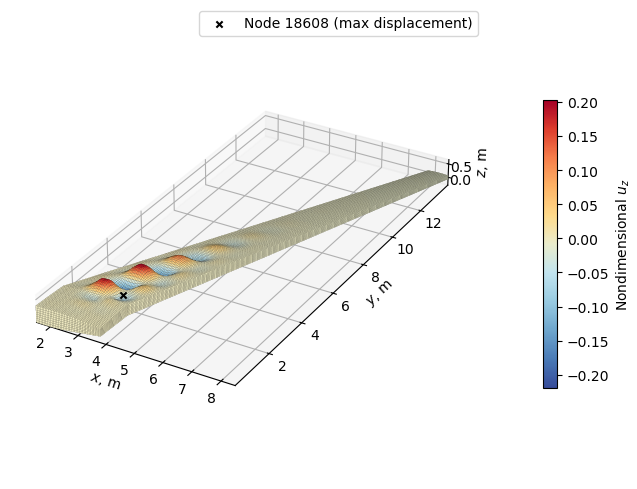


Max-displacement node ID : 18608
Node coordinates [x, y, z] (m): [3.02882401 2.48676316 0.27278431]


In [7]:
%matplotlib widget

# Read op2 file
sol_105_op2_path = os.path.join(ANALYSIS_DIR, f"sol_105_{INPUT_NAME_SUFFIX}.op2")
sol_105_op2 = read_op2(sol_105_op2_path, load_geometry=True, debug=None)

# Extract and print linear buckling load
# Note that the eigenvalues of SOL 105 are buckling load factors, that is to say
# P_buckling/P_applied. Since we applied a reference load of 1 N, the buckling load
# factor is numerically equal to the buckling load in Newtons.
linear_buckling_load = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Linear buckling load: {linear_buckling_load:.2f} N")

# Plot critical buckling mode shape
_, ax, _ = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=AMPLIFICATION_FACTOR,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)

# Mark and record the node with maximum out-of-plane displacement
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_105_op2, displacement_amplification_factor=AMPLIFICATION_FACTOR
)

# Add plot legend, adjust 3D plot settings, and display
ax.legend()
nastran_vs_cuf_utils.adjust_3d_plot(ax)
plt.show()

# Print the ID and coordinates of the node with maximum out-of-plane displacement
print(f"\nMax-displacement node ID : {max_disp_node_id}")
print(f"Node coordinates [x, y, z] (m): {sol_105_op2.nodes[max_disp_node_id].xyz}")

Critical buckling mode is a global buckling of the first few top skin panels after the SOB break, with two half-waves along the chord, which involve also the deformation of the stringers.

### Nonlinear Analyses (SOL 106)

Several arc-length analyses are run, each using different NLPARM convergence settings. All analyses are executed with an applied load of 1.5 times the linear buckling load, which is expected to induce evident buckling deformation.

In [8]:
# Initialize data structures for storing SOL 106 results
sol_106_keys = []  # will store keys for the SOL 106 cases
sol_106_op2s = {}  # will store {key: OP2 object}
sol_106_labels = {}  # will store {key: label} for plotting (legend)

# Define the applied load for the SOL 106 cases as 150% of the linear buckling load
applied_load = linear_buckling_load * 1.5

#### EPSP = EPSU = 5e-6

This is the case with the tightest convergence settings, taken from those used in the SciTech 2025 paper. The table below summarizes the parameters of the NLPARM and NLPCI cards for this case.

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | PU |
| EPSU | $5 \cdot 10^{-6}$ |
| EPSP | $5 \cdot 10^{-6}$ |
| DESITER | 4 |
| MXINC | 600 |

In [9]:
# Define key and label for the SOL 106 case with eps_p = eps_u = 5e-6
nastran_key = "epsp_5e-6"
sol_106_keys.append(nastran_key)
sol_106_labels[nastran_key] = r"$\varepsilon_p = \varepsilon_u = 5 \cdot 10^{-6}$"

# Define NLPARM and NLPCI parameters
conv = "PU"
epsp = 5e-6
epsu = 5e-6
mxinc = 600

##### Set Up and Run

In [10]:
# Build the SOL 106 BDF using the shared helper
sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,  # scale factor applied to the reference unit load
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    mxinc=mxinc,
)

# Create OpenMDAO nonlinear problem
nonlinear_problem = om.Problem(name=f"sol_106_distributed_tip_load")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=INPUT_NAME_SUFFIX,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

# Read op2 file
op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_path, load_geometry=True, debug=None)

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_constant_thickness_distributed_tip_load.bdf completed
Wall time: 112716.0 s


##### First Comparison with CUF

Read load and displacement histories from Nastran analysis and from the equilibrium curve file obtained from the first CUF analysis.

In [11]:
# Find tip nodes (used to compute mean tip deflection)
tip_nodes_ids, _ = stw_utils.find_tip_nodes(stw_layout, sol_106_op2s[nastran_key])

# Read Nastran load and displacement histories for each variant
nastran_loads = {}
nastran_disps = {}

_, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2s[nastran_key], node_ids=list(tip_nodes_ids) + [max_disp_node_id]
)
nastran_loads[nastran_key] = loads
nastran_disps[nastran_key] = disps

# Save equilibrium path to CSV
nastran_vs_cuf_utils.save_equilibrium_path_csv(
    filepath=os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}.csv"),
    load=nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2],
    tip_displacement=stw_utils.calculate_tip_deflection(
        nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
        nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
    ),
    u_z=nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2],
    u_y=nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1],
    local_node_id=max_disp_node_id,
    local_node_coords=sol_106_op2s[nastran_key].nodes[max_disp_node_id].xyz,
)

# Read CUF equilibrium curve
cuf_filepath = os.path.join(ANALYSIS_DIR, "equ_curve_constant_thickness.dat")
cuf_data = nastran_vs_cuf_utils.read_cuf_data(
    cuf_filepath, max_disp_node_id=max_disp_node_id
)
print(f"CUF node ID from file: {cuf_data['node_id']}")
print(f"CUF max applied load : {cuf_data['P[N]'].max():.2f} N")

CUF node ID from file: 18608
CUF max applied load : 400558.60 N


Plot equilibrium paths (load vs displacement). Displacement is monitored at three points:
- $z$-displacement at wingbox tip, serving as an indication of the global displacement of the wingbox. This displacement is nondimensionalized with the semi-span $b/2$.
- $z$-displacement at the max-displacement node observed in the critical buckling mode (linear buckling analysis). This serves as a surrogate of the local out of plane displacement which should be induced by the expected buckling deformation. This displacement is non-dimensionalized with the mean aerodynamic chord $MAC$.
- $y$-displacement at the max-displacement node observed in the critical buckling mode. This serves as a surrogate of the local shortening of the skin panel experiencing the expected buckling deformation. This displacement is nondimensionalized with the mean aerodynamic chord $MAC$.

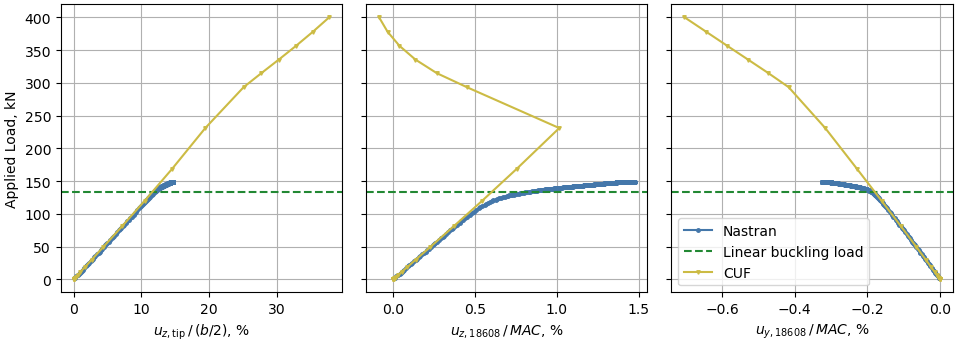

In [12]:
# Extract Nastran load and displacements for plotting
load = nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]
tip_disp = stw_utils.calculate_tip_deflection(
    nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF equilibrium curves
ax_tip.plot(
    cuf_data["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_data["P[N]"] / 1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax_uz.plot(
    cuf_data[f"node {max_disp_node_id} w[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"] / 1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax_uy.plot(
    cuf_data[f"node {max_disp_node_id} v[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"] / 1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

Looking at the tip displacement plot, the CUF curve appears to change slope at a much larger load than the Nastran curve. In addition, the resolution of the CUF curve is very coarse, suggesting that the nonlinear convergence settings are too loose. Furthermore, the local $z$-displacment CUF curve exhibit an unresonable response.

##### Comparison with CUF arc_opt = 3, toll = 1e-4

Read load and displacement histories from the equilibrium curve obtained from a CUF analysis with modified nonlinear solver settings.

In [13]:
# Read CUF equilibrium curve
cuf_filepath = os.path.join(ANALYSIS_DIR, "equ_curve_arcopt_3_tol_10-4.dat")
cuf_data = nastran_vs_cuf_utils.read_cuf_data(
    cuf_filepath, max_disp_node_id=max_disp_node_id
)
print(f"CUF node ID from file: {cuf_data['node_id']}")
print(f"CUF max applied load : {cuf_data['P[N]'].max():.2f} N")

CUF node ID from file: 18608
CUF max applied load : 271222.80 N


Plot equilibrium paths.

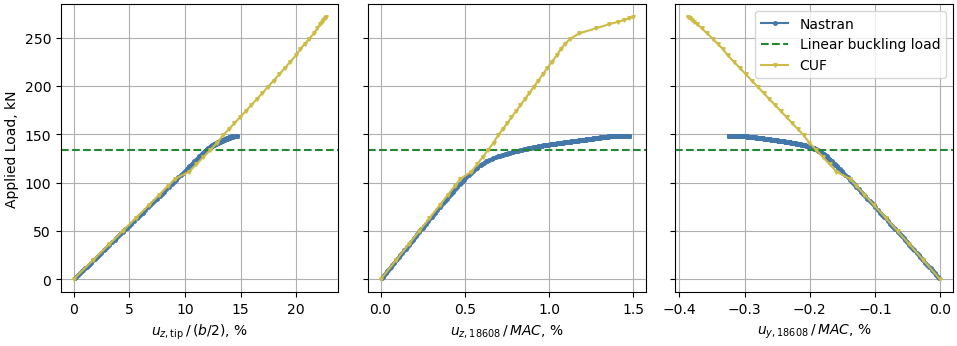

In [14]:
# Extract Nastran load and displacements for plotting
load = nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]
tip_disp = stw_utils.calculate_tip_deflection(
    nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF equilibrium curves
ax_tip.plot(
    cuf_data["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_data["P[N]"] / 1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax_uz.plot(
    cuf_data[f"node {max_disp_node_id} w[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"] / 1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax_uy.plot(
    cuf_data[f"node {max_disp_node_id} v[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"] / 1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

The resolution of the CUF curves is improved. Looking at the local $z$-displacement plot, the CUF curve still appears to change slope at a much larger load than the Nastran curve. At the same time, an unresonable short-lived change of slope can be observed in the CUF curves at approximately 111 kN, requiring more investigation into the CUF nonlinear solver settings.

##### Comparison with CUF 2B4, toll = 1e-4 and toll = 1e-5

Goal: investigate the effect of the CUF arc-length solver tolerance on the equilibrium curve, using the cheaper 2B4 model.

In [15]:
# Define keys, filenames, and labels for CUF 2B4 cases with different tolerances
cuf_keys = [
    "tol_1e-4",
    "tol_1e-5",
]
cuf_filenames = [
    f"equ_curve_constant_thickness_2B4_{cuf_key}.dat" for cuf_key in cuf_keys
]
cuf_labels = [
    "CUF, 2B4, tol = $10^{-4}$",
    "CUF, 2B4, tol = $10^{-5}$",
]
cuf_markers = ["v", "^"]
cuf_colors = [COLORS[1], COLORS[2]]

# Read CUF equilibrium curves
cuf_data = {
    cuf_key: nastran_vs_cuf_utils.read_cuf_data(
        os.path.join(ANALYSIS_DIR, filename), max_disp_node_id=max_disp_node_id
    )
    for cuf_key, filename in zip(cuf_keys, cuf_filenames)
}

Plot equilibrium paths.

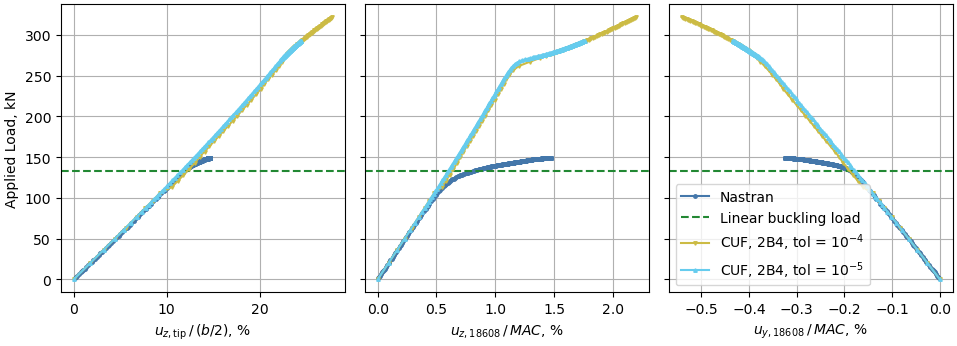

In [16]:
# Extract Nastran load and displacements for plotting
load = nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]
tip_disp = stw_utils.calculate_tip_deflection(
    nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF equilibrium curves
for cuf_key, label, marker, color in zip(cuf_keys, cuf_labels, cuf_markers, cuf_colors):
    ax_tip.plot(
        cuf_data[cuf_key]["w_tip[m]"] / wingGeometry.semiSpan * 100,
        cuf_data[cuf_key]["P[N]"] / 1e3,
        label=label,
        marker=marker,
        color=color,
    )
    ax_uz.plot(
        cuf_data[cuf_key][f"node {max_disp_node_id} w[m]"]
        / wingGeometry.meanAerodynamicChord
        * 100,
        cuf_data[cuf_key]["P[N]"] / 1e3,
        label=label,
        marker=marker,
        color=color,
    )
    ax_uy.plot(
        cuf_data[cuf_key][f"node {max_disp_node_id} v[m]"]
        / wingGeometry.meanAerodynamicChord
        * 100,
        cuf_data[cuf_key]["P[N]"] / 1e3,
        label=label,
        marker=marker,
        color=color,
    )

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

The tol = 1e-4 curve exhibits the same unreasonable short-lived change of slope at approximately 111 kN as observed earlier, while the tol = 1e-5 curve appears to be free of such issue. However, the tip displacement curve with tol = 1e-5 still shows a permanent change of slope at a much larger load than the Nastran curve.

##### Comparison with CUF 2B4 and 3B4, toll = 1e-5

Goal: investigate the effect of the CUF model refinement on the equilibrium curve, using the tight nonlinear solver tolerance of 1e-5.

In [17]:
# Define keys, filenames, and labels for CUF 2B4 cases with different tolerances
cuf_keys = [
    "2B4_tol_1e-5",
    "3B4_tol_1e-5",
]
cuf_filenames = [
    f"equ_curve_constant_thickness_{cuf_key}.dat" for cuf_key in cuf_keys
]
cuf_labels = [
    "CUF, 2B4, tol = $10^{-5}$",
    "CUF, 3B4, tol = $10^{-5}$",
]

# Read CUF equilibrium curves
cuf_data = {
    cuf_key: nastran_vs_cuf_utils.read_cuf_data(
        os.path.join(ANALYSIS_DIR, filename), max_disp_node_id=max_disp_node_id
    )
    for cuf_key, filename in zip(cuf_keys, cuf_filenames)
}

Plot equilibrium paths.

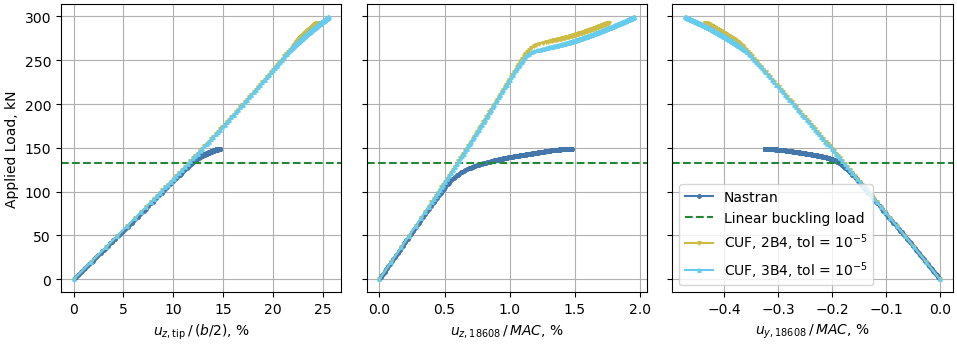

In [18]:
# Extract load and displacements for plotting
load = nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]
tip_disp = stw_utils.calculate_tip_deflection(
    nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF equilibrium curves
for cuf_key, label, marker, color in zip(cuf_keys, cuf_labels, cuf_markers, cuf_colors):
    ax_tip.plot(
        cuf_data[cuf_key]["w_tip[m]"] / wingGeometry.semiSpan * 100,
        cuf_data[cuf_key]["P[N]"] / 1e3,
        label=label,
        marker=marker,
        color=color,
    )
    ax_uz.plot(
        cuf_data[cuf_key][f"node {max_disp_node_id} w[m]"]
        / wingGeometry.meanAerodynamicChord
        * 100,
        cuf_data[cuf_key]["P[N]"] / 1e3,
        label=label,
        marker=marker,
        color=color,
    )
    ax_uy.plot(
        cuf_data[cuf_key][f"node {max_disp_node_id} v[m]"]
        / wingGeometry.meanAerodynamicChord
        * 100,
        cuf_data[cuf_key]["P[N]"] / 1e3,
        label=label,
        marker=marker,
        color=color,
    )

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

The two CUF curves are very close to each other, suggesting that the discrepancy with the Nastran curve is not due to the CUF model refinement.

#### Comparison of Nastran SOL 106 Variants

Both Nastran and CUF nonlinear analyses apply 10% of the reference applied load for the first arc-length step. However, while the CUF analyses always manage to converge to this load level with the employed nonlinear solver settings, the Nastran analysis fails to converge to the same load level and needs to apply many bisections of the applied load to converge (this is driven by the tight convergence tolerances and the number of maximum iterations allowed). To investigate whether the discrepancy between the Nastran and CUF curves is driven by the different nonlinear solver algoritms, additional nonlinear analyses are run with Nastran with the aim of replicating the convergence of the CUF analyses in the first arc-length step.

For this reason we run three additional SOL 106 analyses with the following nonlinear analysis convergence settings:
- *EPSP = EPSU = 1e-5:* this analysis has slightly looser convergence settings than the first case, and it uses in theory the same tolerances employed in the CUF 3B4 case.
- *EPSP = 2.3e-4, EPSU = 1.3e-2 (MAXITER = 40):* this analysis has much looser convergence settings, and it uses the tightest convergence settings that allow the first arc-length step to converge within 3 iterations. MAXITER is increased to 40 to match the value used in the CUF 3B4 case.
- *EPSW = 1e-5 (CONV = W):* this analysis uses the work convergence criterion instead of displacement and load convergence criteria. The tolerance value is chosen in such a way to allow the first arc-length step to converge within 3 iterations.

The four SOL 106 arc-length analyses are summarized in the table below.

| Parameter | EPSP = EPSU = $5 \cdot 10^{-6}$ (baseline) | EPSP = EPSU = $10^{-5}$ | EPSP = $2.3 \cdot 10^{-4}$, EPSU = $1.3 \cdot 10^{-2}$ | EPSW = $10^{-5}$ |
|---|---|---|---|---|
| KMETHOD | ITER | ITER | ITER | ITER |
| KSTEP | −1 | −1 | −1 | −1 |
| MAXITER | 3 | 3 | 40 | 3 |
| CONV | PU | PU | PU | W |
| EPSU | $5×10^{-6}$ | $1×10^{-5}$ | $1.3×10^{-2}$ | — |
| EPSP | $5×10^{-6}$ | $1×10^{-5}$ | $2.3×10^{-4}$ | — |
| EPSW | — | — | — | $1×10^{-6}$ |
| NLPCI type | CRIS | CRIS | CRIS | CRIS |
| DESITER | 4 | 4 | 3 | 4 |
| MXINC | 600 | 500 | 280 | 200 |

Now let's define and run the analyses.

In [19]:
# Each entry defines the key, legend label, and the kwargs forwarded verbatim
# to setup_sol_106_bdf (on top of the fixed base_bdf / load / force / dir args).
SOL_106_VARIANTS = [
    {
        "key": "epsp_1e-5",
        "label": r"$\varepsilon_p = \varepsilon_u = 10^{-5}$",
        "bdf_kwargs": {"conv": "PU", "eps_p": 1e-5, "eps_u": 1e-5, "mxinc": 500},
    },
    {
        "key": "epsp_2p3e-4",
        "label": r"$\varepsilon_p = 2.3 \cdot 10^{-4}$, $\varepsilon_u = 1.3 \cdot 10^{-2}$",
        "bdf_kwargs": {
            "conv": "PU",
            "eps_p": 2.3e-4,
            "eps_u": 1.3e-2,
            "max_iter": 40,
            "desiter": 3,
            "mxinc": 280,
        },
    },
    {
        "key": "epsw_1e-5",
        "label": r"$\varepsilon_w = 10^{-5}$",
        "bdf_kwargs": {"conv": "W", "eps_w": 1e-5, "mxinc": 200},
    },
]

# Iterate over the SOL 106 variants
for variant in SOL_106_VARIANTS:
    key = variant["key"]
    sol_106_keys.append(key)
    sol_106_labels[key] = variant["label"]

    # Build the SOL 106 BDF passing through the variant-specific kwargs
    sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
        base_bdf=distributed_tip_load_bdf,
        load_scale_factor=applied_load,
        force_set_id=FORCE_SET_ID,
        analysis_directory_path=ANALYSIS_DIR,
        **variant["bdf_kwargs"],
    )

    # Create and run the OpenMDAO nonlinear problem for this SOL 106 variant
    nonlinear_problem = om.Problem(name=f"sol_106_distributed_tip_load_{key}")
    nonlinear_problem.model = stw_utils.NastranAnalysis(
        layout=stw_layout,
        input_name_suffix=f"{INPUT_NAME_SUFFIX}_{key}",
        analysis_directory_path=ANALYSIS_DIR,
        bdf=sol_106_bdf,
        run_flag=False,
    )
    nonlinear_problem.setup()
    nonlinear_problem.run_model()

    # Read the SOL 106 OP2 results for this variant
    op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{key}.op2")
    sol_106_op2s[key] = read_op2(op2_path, load_geometry=True, debug=None)

    # Read Nastran load and displacement histories for the tip nodes and max-displacement node
    _, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
        op2=sol_106_op2s[key], node_ids=list(tip_nodes_ids) + [max_disp_node_id]
    )
    nastran_loads[key] = loads
    nastran_disps[key] = disps

    # Save equilibrium path to CSV
    nastran_vs_cuf_utils.save_equilibrium_path_csv(
        filepath=os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{key}.csv"),
        load=nastran_loads[key][FIRST_SUBCASE_ID][:, 2],
        tip_displacement=stw_utils.calculate_tip_deflection(
            nastran_disps[key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
            nastran_disps[key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
        ),
        u_z=nastran_disps[key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2],
        u_y=nastran_disps[key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1],
        local_node_id=max_disp_node_id,
        local_node_coords=sol_106_op2s[key].nodes[max_disp_node_id].xyz,
    )

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_constant_thickness_distributed_tip_load_epsp_1e-5.bdf completed
Wall time: 89178.0 s


/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_constant_thickness_distributed_tip_load_epsp_2p3e-4.bdf completed
Wall time: 26223.0 s


/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_constant_thickness_distributed_tip_load_epsw_1e-5.bdf completed
Wall time: 16683.0 s


Plot equilibrium paths: tip deflection and local displacements at the critical node.

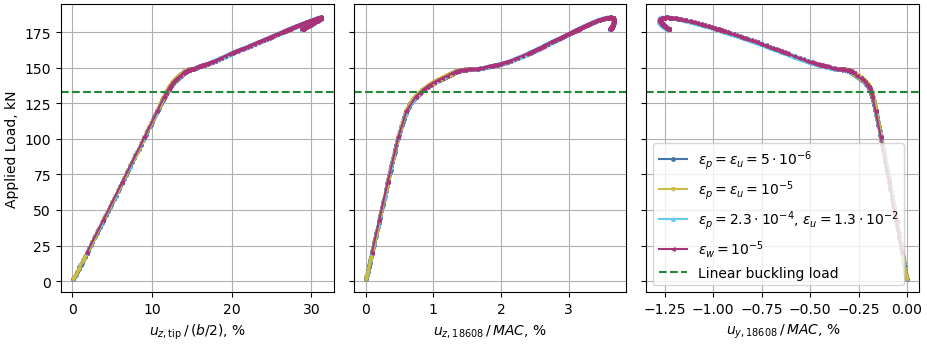

In [20]:
# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Iterate over the SOL 106 variants again to plot their curves
for i, key in enumerate(sol_106_keys):
    # Extract load and displacements for plotting
    load = nastran_loads[key][FIRST_SUBCASE_ID][:, 2]
    tip_disp_key = stw_utils.calculate_tip_deflection(
        nastran_disps[key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
        nastran_disps[key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
    )
    u_z = nastran_disps[key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
    u_y = nastran_disps[key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

    # Define plotting kwargs for this variant (label, marker, color)
    plot_kwargs = dict(
        label=sol_106_labels[key],
        marker=MARKERS[i % len(MARKERS)],
        color=COLORS[i % len(COLORS)],
    )

    # Plot the curves for this variant
    ax_tip.plot(tip_disp_key / wingGeometry.semiSpan * 100, load / 1e3, **plot_kwargs)
    ax_uz.plot(u_z / wingGeometry.meanAerodynamicChord * 100, load / 1e3, **plot_kwargs)
    ax_uy.plot(u_y / wingGeometry.meanAerodynamicChord * 100, load / 1e3, **plot_kwargs)

# Iterate over all axes to add the linear buckling reference line and grid
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

All the curves appear essentially on top of each other, suggesting that the Nastran nonlinear analysis is not sensitive to the employed nonlinear solver settings, meaning that we are likely observing a converged solution with respect to the nonlinear solver settings. Consequently, the reason for the discrepancy with the CUF curves has to be found elsewhere.

Interestingly, the curves obtained with looser convergence settings (EPSP = 2.3e-4, EPSU = 1.3e-2 and EPSW = 1e-5) capture a larger portion of the structural response, since the looser tolerances allow to advance the analysis with a smaller number of arc-length increments. This larger portion of the structural response shows the onset of a snap-through instability in the part where the applied load decreases after reaching a maximum.

#### Comparison between Nastran EPSP = EPSU = 1e-5 and CUF Free Stringers Analysis

It was discovered that all CUF analyses executed so far employ a wingbox model where the intersection between stringers and ribs is modelled with coincident nodes (i.e., the stringer nodes are shared with the rib nodes), making the stringers effectively "fixed" to the ribs. However, the Nastran model uses separate nodes for ribs and stringers at their intersection, making the stringers effectively "free" to deform with respect to the ribs (even if CQUAD4 elements have a graphic compenetration, the stringers can deform freely like they were passing through mouseholes typical of wingbox constructions). This means that the CUF model is effectively stiffer than the Nastran model, which could be a reason for the discrepancy between the Nastran and CUF curves.

To investigate the contribution of this modelling difference to the discrepancy between Nastran and CUF curves, a new CUF analysis is run with a model where stringers and ribs have separate nodes at their intersection, making the stringers free to deform with respect to the ribs like in the Nastran model.

In [21]:
# Define Nastran key for the SOL 106 variant to compare with the CUF Free Stringers equilibrium curve
nastran_key = "epsp_1e-5"

# Read CUF Free Stringers equilibrium curve
cuf_filepath = os.path.join(ANALYSIS_DIR, "equ_curve_free_stringers.dat")
cuf_free_stringers = nastran_vs_cuf_utils.read_cuf_data(
    cuf_filepath, max_disp_node_id=max_disp_node_id
)
print(f"CUF node ID from file: {cuf_free_stringers['node_id']}")
print(f"CUF max applied load : {cuf_free_stringers['P[N]'].max():.2f} N")

CUF node ID from file: 18608
CUF max applied load : 217049.27 N


Plot equilibrium paths.

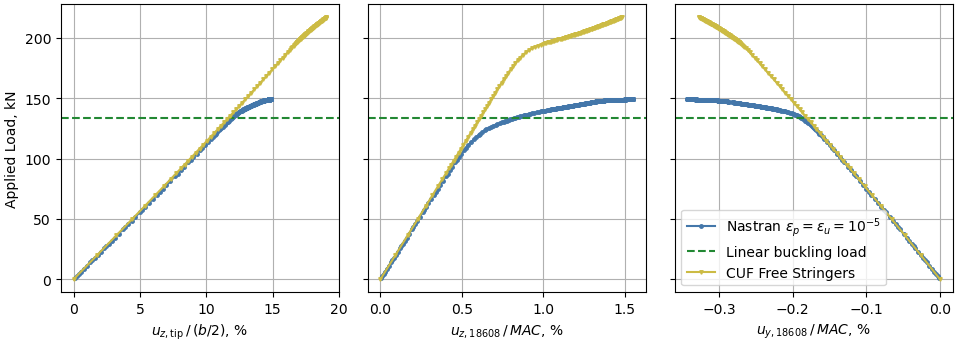

In [22]:
# Extract load and displacements for the selected SOL 106 variant
load = nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]
tip_disp = stw_utils.calculate_tip_deflection(
    nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    load / 1e3,
    marker="o",
    color=COLORS[0],
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label=f"Nastran {sol_106_labels[nastran_key]}",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF Free Stringers equilibrium curves
ax_tip.plot(
    cuf_free_stringers["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_free_stringers["P[N]"] / 1e3,
    label="CUF Free Stringers",
    marker="v",
    color=COLORS[1],
)
ax_uz.plot(
    cuf_free_stringers[f"node {max_disp_node_id} w[m]"]
    / wingGeometry.meanAerodynamicChord
    * 100,
    cuf_free_stringers["P[N]"] / 1e3,
    label="CUF Free Stringers",
    marker="v",
    color=COLORS[1],
)
ax_uy.plot(
    cuf_free_stringers[f"node {max_disp_node_id} v[m]"]
    / wingGeometry.meanAerodynamicChord
    * 100,
    cuf_free_stringers["P[N]"] / 1e3,
    label="CUF Free Stringers",
    marker="v",
    color=COLORS[1],
)

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

The change of slope in the CUF curve still appears at a much larger load than in the Nastran curve, but it has shifted to a smaller load level than in the previous CUF analyses (190 kN vs 260 kN), indicating that the modelling difference between Nastran and CUF with respect to the stringer-rib connection had a significant contribution to the discrepancy between Nastran and CUF curves observed earlier, but it is not the only reason for such discrepancy.

## Nastran Analyses with CQUAD4 Element Offset

An observation was made on the way the Nastran and CUF models build the thickness of the different structural parts (mainly skins and spars). The CQUAD4 elements in the Nastran model are defined at the Outer Mold Line (OML) of the wing, and their position corresponds to the mid-surface of the element. The thickness of the elements is built symmetrically with respect to the mid-surface, with half of the thickness defined at the inner side of the OML and half of the thickness defined at the outer side of the OML. On the other hand, the CUF model builds the thickness of the skins and spars from the nodes on the outer mold line towards the outside. This means that the CUF model results in a cross-section that is effectively larger than the Nastran model, which can contribute to making the CUF model stiffer than the Nastran model.

For this reason, additional Nastran analyses are run employing an offset in the CQUAD4 elements, in order to move the mid-surface of the elements by half of the thickness towards the outside of the wing, making the Nastran model more similar to the CUF model in terms of how the thickness is built.

### Linear Buckling Analysis (SOL 105)

#### Set Up

Before applying the offset to the CQUAD4 elements, we visualize the orientation of the elements' normal vectors to make sure that the offset is applied in the correct direction.

subcase=1 already exists...skipping


U_SKIN


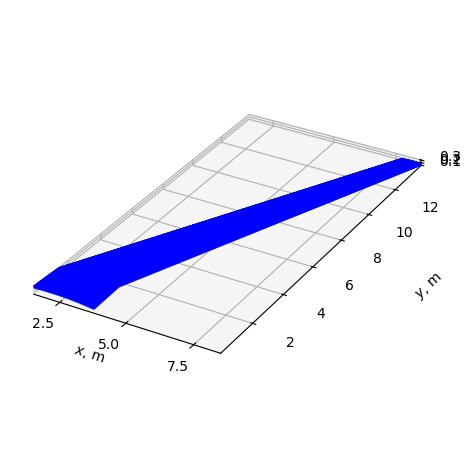

L_SKIN


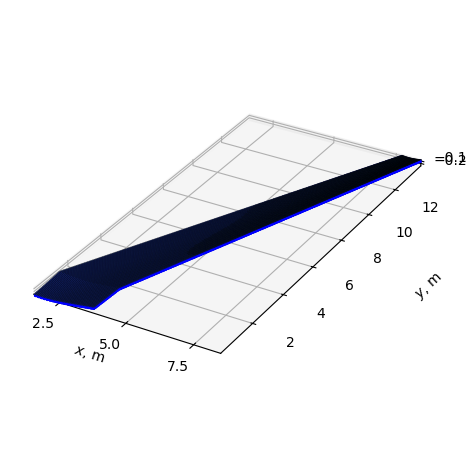

SPAR.00


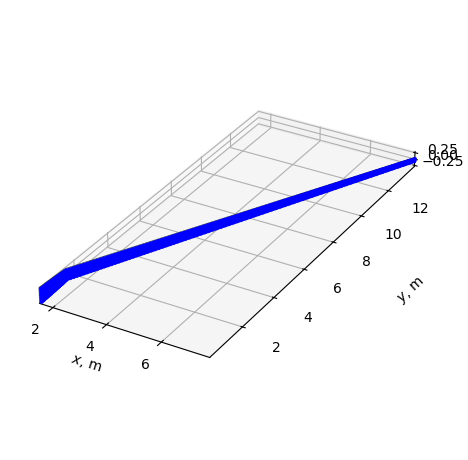

SPAR.10


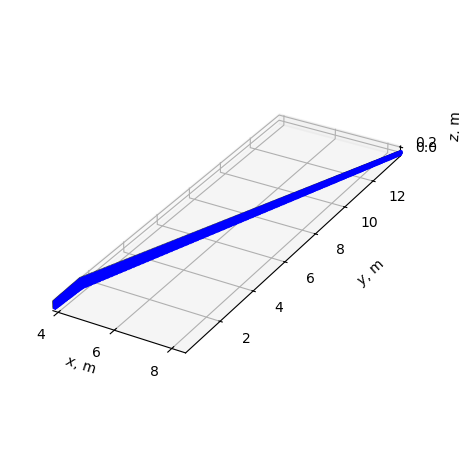

In [23]:
# Create deep copy of the load BDF for SOL 105
sol_105_offset_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up linear buckling solution with eigenvalue method set
pynastran_utils.set_up_sol_105(
    bdf=sol_105_offset_bdf,
    static_load_set_id=FORCE_SET_ID,
    method_set_id=METHOD_SET_ID,
)

# Request element stress output for post-processing
sol_105_offset_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

# Find element ids for the specified parts
element_ids_dict = stw_utils.find_element_ids(
    stw_layout, ["U_SKIN", "L_SKIN", "SPAR.00", "SPAR.10"]
)

# Plot element normals to verify correct orientation before applying offsets
stw_utils.plot_elements_normals(sol_105_offset_bdf, element_ids_dict)

We observe that the normal vectors of the CQUAD4 elements of the skins and the spars are all oriented towards the outside of the wing, except for the front spar elements. This means that we need to use a positive offset value for the skin and rear spar elements, while we need to use a negative offset value for the front spar elements.

In [24]:
# Add offset to top skin CQUAD4 elements
for eid in element_ids_dict["U_SKIN"]:
    sol_105_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to bottom skin CQUAD4 elements
for eid in element_ids_dict["L_SKIN"]:
    sol_105_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to front spar CQUAD4 elements
for eid in element_ids_dict["SPAR.00"]:
    # Minus sign is needed to offset in the correct direction since the front spar normals point inwards (towards the rear spar)
    sol_105_offset_bdf.elements[eid].zoffset = -wingGeometry.panelThickness / 2

# Add offset to rear spar CQUAD4 elements
for eid in element_ids_dict["SPAR.10"]:
    sol_105_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

#### Run

In [25]:
# Define suffix for this analysis variant
analysis_suffix = "outward_offset"

# Define OpenMDAO linear buckling problem
linear_problem = om.Problem(name=f"sol_105_{analysis_suffix}")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=analysis_suffix,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_105_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
linear_problem.setup()
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_105_outward_offset.bdf completed
Wall time: 39.0 s


#### Results

Linear buckling load: 139240.36 N


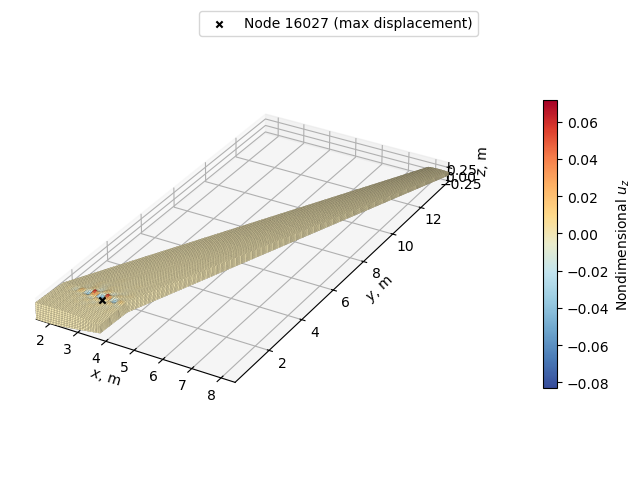


Max-displacement node ID : 16027
Node coordinates [x, y, z] (m): [3.00044643 1.3501     0.29041465]


In [26]:
# Read op2 file
sol_105_op2_path = os.path.join(ANALYSIS_DIR, f"sol_105_{analysis_suffix}.op2")
sol_105_op2 = read_op2(sol_105_op2_path, load_geometry=True, debug=None)

# Extract and print linear buckling load
# Note that the eigenvalues of SOL 105 are buckling load factors, that is to say
# P_buckling/P_applied. Since we applied a reference load of 1 N, the buckling load
# factor is numerically equal to the buckling load in Newtons.
linear_buckling_load = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Linear buckling load: {linear_buckling_load:.2f} N")

# Plot critical buckling mode shape
_, ax, _ = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=AMPLIFICATION_FACTOR,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)

# Mark and record the node with maximum out-of-plane displacement
offset_model_max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_105_op2, displacement_amplification_factor=AMPLIFICATION_FACTOR
)

# Add plot legend, adjust 3D plot settings, and display
ax.legend()
nastran_vs_cuf_utils.adjust_3d_plot(ax)
plt.show()

# Print the ID and coordinates of the node with maximum out-of-plane displacement
print(f"\nMax-displacement node ID : {offset_model_max_disp_node_id}")
print(
    f"Node coordinates [x, y, z] (m): {sol_105_op2.nodes[offset_model_max_disp_node_id].xyz}"
)

As expected, the linear buckling load increases with respect to the previous Nastran analysis without offset, since the wingbox is effectively stiffer with the offset. The stiffening of the model is also reflected in the critical buckling mode shape, which now is confined within the rib-stringer bays just before the SOB break.

### Nonlinear Analysis (SOL 106)

#### Set Up and Run

We use the solver settings summarized in the table below, (same as in the analysis with EPSP = EPSU = 1e-5 without offset).

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | PU |
| EPSU | $10^{-5}$ |
| EPSP | $10^{-5}$ |
| DESITER | 4 |
| MXINC | 500 |

In [27]:
# Define NLPARM and NLPCI parameters
conv = "PU"
epsp = 1e-5
epsu = 1e-5
mxinc = 500

# Build the SOL 106 BDF using the shared helper
sol_106_offset_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,  # scale factor applied to the reference unit load
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    mxinc=mxinc,
)

# Add offset to top skin CQUAD4 elements
for eid in element_ids_dict["U_SKIN"]:
    sol_106_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to bottom skin CQUAD4 elements
for eid in element_ids_dict["L_SKIN"]:
    sol_106_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to front spar CQUAD4 elements
for eid in element_ids_dict["SPAR.00"]:
    sol_106_offset_bdf.elements[eid].zoffset = -wingGeometry.panelThickness / 2

# Add offset to rear spar CQUAD4 elements
for eid in element_ids_dict["SPAR.10"]:
    sol_106_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Create OpenMDAO nonlinear problem
nonlinear_problem = om.Problem(name=f"sol_106_{analysis_suffix}")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=analysis_suffix,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_offset_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

# Read op2 file
op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{analysis_suffix}.op2")
sol_106_op2 = read_op2(op2_path, load_geometry=True, debug=None)

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_outward_offset.bdf completed
Wall time: 99224.0 s


#### Comparison with CUF Free Stringers Analysis

We first compare the results of the Nastran analysis with offset with the CUF analysis with free stringers. For this comparison we'll still use the monitor node corresponding to the maximum displacement node observed in the critical buckling mode of the Nastran analysis without offset, since the equilibrium curve data for the CUF analysis includes the displacements at that node.

In [28]:
# Extract Nastran load and displacements
# Local displacements are extracted at the "old" max-displacement node ID, because CUF Free Stringer equilibrium curve was computed at that node
_, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2, node_ids=list(tip_nodes_ids) + [max_disp_node_id]
)
load = loads[FIRST_SUBCASE_ID][:, 2]
tip_disp = stw_utils.calculate_tip_deflection(
    disps[tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    disps[tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
u_z = disps[max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = disps[max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Save equilibrium path to CSV
nastran_vs_cuf_utils.save_equilibrium_path_csv(
    filepath=os.path.join(ANALYSIS_DIR, f"sol_106_{analysis_suffix}_node{max_disp_node_id}.csv"),
    load=load,
    tip_displacement=tip_disp,
    u_z=u_z,
    u_y=u_y,
    local_node_id=max_disp_node_id,
    local_node_coords=sol_106_op2.nodes[max_disp_node_id].xyz,
)

Plot equilibrium paths.

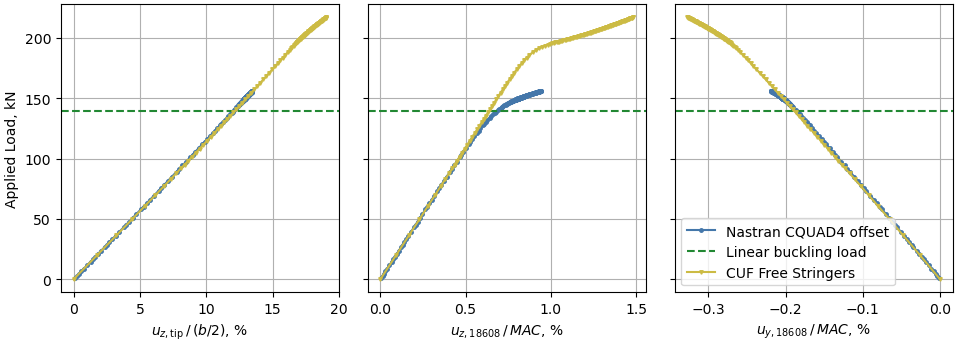

In [29]:
# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    load / 1e3,
    marker="o",
    color=COLORS[0],
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran CQUAD4 offset",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF Free Stringers equilibrium curves
ax_tip.plot(
    cuf_free_stringers["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_free_stringers["P[N]"] / 1e3,
    label="CUF Free Stringers",
    marker="v",
    color=COLORS[1],
)
ax_uz.plot(
    cuf_free_stringers[f"node {max_disp_node_id} w[m]"]
    / wingGeometry.meanAerodynamicChord
    * 100,
    cuf_free_stringers["P[N]"] / 1e3,
    label="CUF Free Stringers",
    marker="v",
    color=COLORS[1],
)
ax_uy.plot(
    cuf_free_stringers[f"node {max_disp_node_id} v[m]"]
    / wingGeometry.meanAerodynamicChord
    * 100,
    cuf_free_stringers["P[N]"] / 1e3,
    label="CUF Free Stringers",
    marker="v",
    color=COLORS[1],
)

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

The slope change of the Nastran curve has shifted to a slightly larger load level, in line with the increase of the linear buckling load, but it is still significantly smaller than the load level at which the slope change in the CUF curve occurs, suggesting that the thickness modelling differences between Nastran and CUF are not the only reason for the discrepancy between Nastran and CUF curves.

#### Comparison with CUF Q9 Analyses

A further attempt is made on the CUF model side. So far, all CUF models were built using Q4 elements in the cross-sectional expansion. To investigate whether there might be an effect of element convergence in the cross-sectional exapansion, the analyses with 2 and 3 B4 elements between successive ribs are repeated employing Q9 elements in the cross-sectional expansion instead of Q4 elements. This time, the local displacement is monitored at the max-displacement node observed in the critical buckling mode of the Nastran analysis with offset.

In [30]:
# Extract Nastran displacements at new maximum displacement node
_, _, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2, node_ids=[offset_model_max_disp_node_id]
)
u_z = disps[offset_model_max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = disps[offset_model_max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Save equilibrium path to CSV (load and tip_disp reuse the values from the previous cell)
nastran_vs_cuf_utils.save_equilibrium_path_csv(
    filepath=os.path.join(ANALYSIS_DIR, f"sol_106_{analysis_suffix}_node{offset_model_max_disp_node_id}.csv"),
    load=load,
    tip_displacement=tip_disp,
    u_z=u_z,
    u_y=u_y,
    local_node_id=offset_model_max_disp_node_id,
    local_node_coords=sol_106_op2.nodes[offset_model_max_disp_node_id].xyz,
)

# Define Q9 CUF analysis variants
q9_variants = [
    {"key": "q9_2b4", "filename": "equ_curve_q9_2b4.dat", "label": "CUF Q9, 2B4"},
    {"key": "q9_3b4", "filename": "equ_curve_q9_3b4.dat", "label": "CUF Q9, 3B4"},
]
q9_markers = ["v", "^"]

# Read CUF Q9 equilibrium curves
q9_data = {}
for variant in q9_variants:
    cuf_filepath = os.path.join(ANALYSIS_DIR, variant["filename"])
    q9_data[variant["key"]] = nastran_vs_cuf_utils.read_cuf_data(
        cuf_filepath, max_disp_node_id=offset_model_max_disp_node_id
    )
    print(f"{variant['label']} node ID from file: {q9_data[variant['key']]['node_id']}")
    print(
        f"{variant['label']} max applied load : {q9_data[variant['key']]['P[N]'].max():.2f} N"
    )

CUF Q9, 2B4 node ID from file: 16027
CUF Q9, 2B4 max applied load : 189938.39 N
CUF Q9, 3B4 node ID from file: 16027
CUF Q9, 3B4 max applied load : 186451.02 N


Plot equilibrium paths.

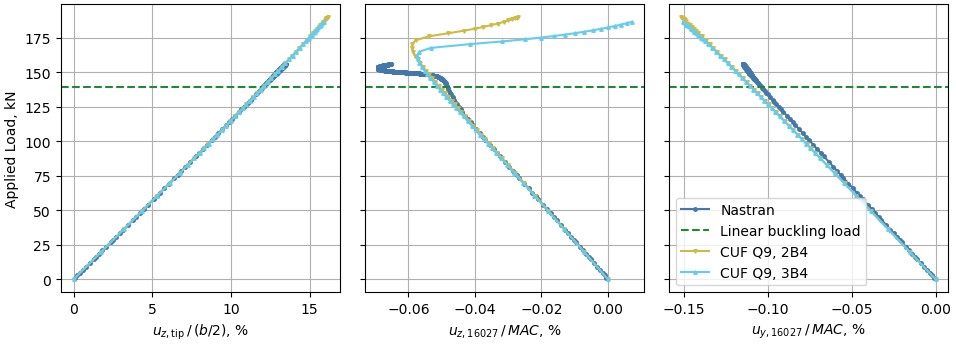

In [31]:
# Create figure with 3 subplots sharing the y-axis
fig, (ax_tip, ax_uz, ax_uy) = plt.subplots(
    1, 3, sharey=True, figsize=(TEXTWIDTH_INCHES * 1.5, FIG_HEIGHT_INCHES)
)

# Plot Nastran curves
ax_tip.plot(
    tip_disp / wingGeometry.semiSpan * 100, load / 1e3, marker="o", color=COLORS[0]
)
ax_uz.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    marker="o",
    color=COLORS[0],
)
ax_uy.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    load / 1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference line
for ax in (ax_tip, ax_uz, ax_uy):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

# Plot CUF Q9 equilibrium curves
for i, variant in enumerate(q9_variants):
    data = q9_data[variant["key"]]
    color = COLORS[i + 1]
    marker = q9_markers[i]
    ax_tip.plot(
        data["w_tip[m]"] / wingGeometry.semiSpan * 100,
        data["P[N]"] / 1e3,
        label=variant["label"],
        marker=marker,
        color=color,
    )
    ax_uz.plot(
        data[f"node {offset_model_max_disp_node_id} w[m]"]
        / wingGeometry.meanAerodynamicChord
        * 100,
        data["P[N]"] / 1e3,
        label=variant["label"],
        marker=marker,
        color=color,
    )
    ax_uy.plot(
        data[f"node {offset_model_max_disp_node_id} v[m]"]
        / wingGeometry.meanAerodynamicChord
        * 100,
        data["P[N]"] / 1e3,
        label=variant["label"],
        marker=marker,
        color=color,
    )

# Set axis labels, legend, and display the plot
ax_tip.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax_uz.set_xlabel(f"$u_{{z,{offset_model_max_disp_node_id}}}\\,/\\,MAC$, %")
ax_uy.set_xlabel(f"$u_{{y,{offset_model_max_disp_node_id}}}\\,/\\,MAC$, %")
ax_tip.set_ylabel("Applied Load, kN")
ax_uy.legend()
plt.tight_layout()
plt.show()

The change of slope between the Nastran and CUF curves is now much closer, at least looking at the local $z$-displacement plot. At the same time, the response obtained in the Nastran analysis appears to have a more complex behavior. The evolution of the deformation in the top skin panel just before the SOB break should be reviewed in more detail to understand whether the Nastran and CUF analyses are actually capturing the same or a different structural response.